# SI-a · InvOLS drift and the absolute pm/V scale (Phase 2f)

Every checkpoint-based pm/V number in the SCM-PIT-B analysis converts raw lock-in volts with
**InvOLS(x) from the pre-flight walk**, measured once at the start of each campaign. The
R2 load-extension audit found that the calibration had aged ~10 % by the next morning and
put a blanket 10 % systematic on every absolute d33.

In fact each laser stop was followed by a force curve that re-measured InvOLS. Those values
are in the force-curve notes, so the calibration can be reconstructed at every stage and
position (`fmmpaper.calib`), and the reported numbers corrected with the InvOLS that applied
when and where the spectra were taken.

**Two traps handled by `calib.timeline`:**
- A force-curve file is time-stamped when the *next* curve starts. Its time therefore falls in
  the following position's interval (a one-position lag, shown below).
- Out-of-range retries (InvOLS above the pre-flight maximum) are rejected curves and are dropped.

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


In [2]:
import datetime as dt
from fmmpaper import calib
CAMPAIGNS = {"R1": ("DomainsB_SCMPIT", dt.datetime(2026, 9, 20, 11)),
             "R2": ("DomainsB_SCMPIT_R2", dt.datetime(2026, 9, 20, 22))}
tl = {tag: calib.timeline(c, d0) for tag, (c, d0) in CAMPAIGNS.items()}
naive = {tag: calib.timeline(c, d0, lag=0) for tag, (c, d0) in CAMPAIGNS.items()}
for tag, t in tl.items():
    print(tag, len(t), "force curves assigned to laser stops")

R1 278 force curves assigned to laser stops
R2 257 force curves assigned to laser stops


## Evidence for the one-position lag

,R1,R2
"sd, lag 0",3.578,2.855
"sd, lag 1",0.032,0.019


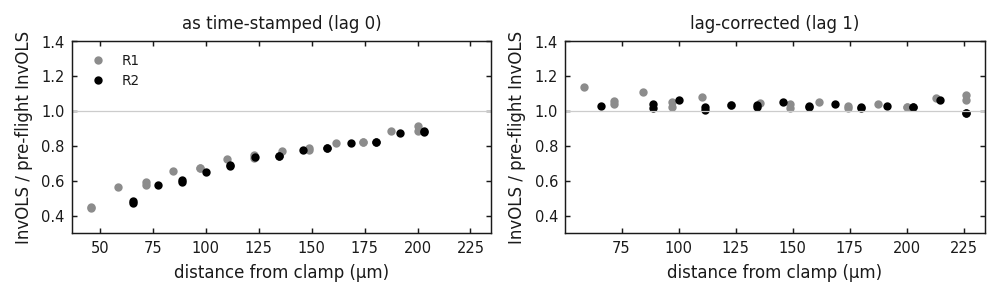

In [3]:
walks = ["10_bias_survey", "20_wideband_fast", "21_wideband_validation"]
fig, axs = fp.figure("double", aspect=0.3, ncols=2)
for ax, (lab, T) in zip(axs, (("as time-stamped (lag 0)", naive), ("lag-corrected (lag 1)", tl))):
    for tag, t in T.items():
        d = t[t.stage.isin(walks)]
        ax.plot(d.x_um - 6.1, d.ratio, "o", ms=3, color="0.55" if tag == "R1" else "k", label=tag)
    ax.set_ylim(0.3, 1.4); ax.axhline(1, color="0.8", lw=0.6)
    ax.set_title(lab); ax.set_xlabel("distance from clamp (µm)"); ax.set_ylabel("InvOLS / pre-flight InvOLS")
axs[0].legend()
fig.tight_layout(); fp.save(fig, "SIa_lag_evidence")
pd.DataFrame({tag: [naive[tag][naive[tag].stage.isin(walks)].ratio.std(),
                    tl[tag][tl[tag].stage.isin(walks)].ratio.std()] for tag in tl},
             index=["sd, lag 0", "sd, lag 1"]).round(3)

## The calibration timeline

/tmp/ipykernel_439/3571649460.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  factors.round(3)


n             t_start  median     sd     lo  \
   stage                                                                   
R1 10_bias_survey            7 2026-09-20 12:57:57   1.026  0.027  1.016   
   20_wideband_fast          7 2026-09-20 13:39:26   1.038  0.014  1.022   
   21_wideband_validation    7 2026-09-20 13:48:41   1.077  0.036  1.038   
   30_dense_grid           174 2026-09-20 14:32:06   1.086  0.065  1.037   
   40_load_ladder           56 2026-09-20 18:37:18   1.158  0.178  0.547   
   50_quant_imaging          2 2026-09-20 19:47:33   1.163  0.070  1.113   
   60_lowac_30mV             1 2026-09-20 20:31:53   1.210    NaN  1.210   
   70_ac_series             15 2026-09-20 21:17:54   1.212  0.006  1.204   
   80_closeout               9 2026-09-20 22:24:47   1.212  0.153  1.120   
R2 10_bias_survey            8 2026-09-20 23:23:05   1.023  0.014  0.988   
   20_wideband_fast          7 2026-09-21 00:04:15   1.025  0.016  0.990   
   21_wideband_validation    6 2026-09-21 00:13:36   1.044  0.014  1.031   
   50_quant_imaging          2 2026-09-21 00:22:03   1.058  0.012  1.049   
   60_lowac_30mV             1 2026-09-21 01:04:25   1.063    NaN  1.063   
   70_ac_series             17 2026-09-21 01:20:10   1.049  0.006  1.041   
   75_dense_grid           156 2026-09-21 02:01:10   1.060  0.052  0.973   
   80_closeout              10 2026-09-21 05:17:40   1.099  0.298  0.173   
   40_load_ladder           40 2026-09-21 08:02:49   1.153  0.106  1.009   
   41_bias_vs_load           3 2026-09-21 08:59:48   1.231  0.012  1.225   
   42_postcheck              7 2026-09-21 09:12:24   1.235  0.173  1.058   

                              hi  
   stage                          
R1 10_bias_survey          1.092  
   20_wideband_fast        1.063  
   21_wideband_validation  1.137  
   30_dense_grid           1.324  
   40_load_ladder          1.525  
   50_quant_imaging        1.212  
   60_lowac_30mV           1.210  
   70_ac_series            1.223  
   80_closeout             1.612  
R2 10_bias_survey          1.030  
   20_wideband_fast        1.041  
   21_wideband_validation  1.064  
   50_quant_imaging        1.067  
   60_lowac_30mV           1.063  
   70_ac_series            1.058  
   75_dense_grid           1.206  
   80_closeout             1.186  
   40_load_ladder          1.495  
   41_bias_vs_load         1.248  
   42_postcheck            1.584

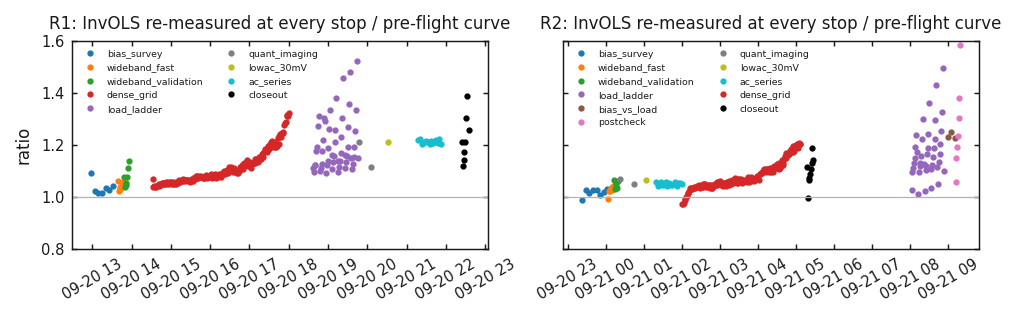

In [4]:
STAGE_C = {"bias_survey": "#1f77b4", "wideband_fast": "#ff7f0e", "wideband_validation": "#2ca02c",
           "dense_grid": "#d62728", "load_ladder": "#9467bd", "bias_vs_load": "#8c564b",
           "postcheck": "#e377c2", "quant_imaging": "#7f7f7f", "lowac_30mV": "#bcbd22",
           "ac_series": "#17becf", "closeout": "#000000"}
kind = lambda st: st.split("_", 1)[1]
fig, axs = fp.figure("double", aspect=0.32, ncols=2, sharey=True)
for ax, (tag, t) in zip(axs, tl.items()):
    for st, d in t.groupby("stage"):
        ax.plot(d.t, d.ratio, "o", ms=2, color=STAGE_C.get(kind(st), "0.5"), label=kind(st))
    ax.axhline(1, color="0.7", lw=0.6); ax.set_ylim(0.8, 1.6)
    ax.set_title(f"{tag}: InvOLS re-measured at every stop / pre-flight curve")
    ax.tick_params(axis="x", rotation=30)
axs[0].set_ylabel("ratio")
for ax in axs:
    ax.legend(fontsize=4.5, ncol=2, loc="upper left")
fig.tight_layout(); fp.save(fig, "SIa_invols_timeline")
factors = pd.concat({tag: calib.stage_factors(t) for tag, t in tl.items()})
factors.round(3)

**Reading the timeline.**
- Within the first hour of each campaign the calibration has moved +2–8 %. This covers the
  bias survey (+2.3 % R2, +2.6 % R1), the live wideband capture and the validation.
- It keeps rising slowly: +6–9 % by the dense map and +10–21 % by the close-out.
- At a fixed position, repeated force curves agree to 0.6 % (AC series, 15–17 curves over
  35–40 min), so the scatter is not measurement noise.
- The ratio depends on position and on load. Along the load-ladder walks it rises from
  ~1.02 at the free end to 1.2–1.5 near the base, and it grows with load.
- Within each dense map (3.2–3.6 h, walked free end → base) the ratio climbs from ~1.0–1.04
  to 1.2–1.3. The 45-min bias-survey walk over the same positions is flat (0.99–1.03), so
  this climb is mainly drift in time, not a position effect. Dense-map spectra taken late,
  near the base, carry the largest factors. The static
  deflection shape itself changed, so a single scale factor cannot correct a whole stage.
  Per-position factors are used below.

## Correction 1: stage-1 d33 (bias survey), per position

In [5]:
VAC = 1.0
corr = {}
for tag in ("R1", "R2"):
    s = F.load(f"scmpitB_{tag.lower()}_bias")
    _, _, ref = calib.preflight_curve(CAMPAIGNS[tag][0])
    f_meas = lambda x, _tl=tl[tag], _ref=ref: float(_ref(x) * calib.factor_at(_tl, "10_bias_survey", x)[0])
    t_old = domains.transfer_table(s, ref, VAC)
    t_new = domains.transfer_table(s, f_meas, VAC)
    corr[tag] = pd.DataFrame(dict(x_clamp_um=t_old.x_clamp_um, factor=t_new.invols / t_old.invols,
                                  d33_qs_preflight=t_old.d33_qs, d33_qs_measured=t_new.d33_qs))
    interior = t_old.x_um < t_old.x_um.max()
    print(f"{tag}: median d33_QS (interior) {np.median(t_old.d33_qs[interior]):.2f} -> "
          f"{np.median(t_new.d33_qs[interior]):.2f} pm/V; factor median "
          f"{np.median(corr[tag].factor):.3f}, range {corr[tag].factor.min():.3f}-{corr[tag].factor.max():.3f}")
pd.concat(corr).round(3)

R1: median d33_QS (interior) 7.87 -> 8.13 pm/V; factor median 1.026, range 1.016-1.092


R2: median d33_QS (interior) 8.81 -> 9.03 pm/V; factor median 1.023, range 0.988-1.030


x_clamp_um  factor  d33_qs_preflight  d33_qs_measured
R1 0        45.9   1.026             8.374            8.594
   1        71.6   1.041             8.477            8.822
   2        97.3   1.026             8.344            8.563
   3       123.0   1.034             7.865            8.132
   4       148.8   1.016             7.712            7.838
   5       174.5   1.016             7.527            7.646
   6       200.2   1.022             7.429            7.594
   7       225.9   1.092             7.241            7.909
R2 0        65.9   1.030             9.669            9.961
   1        88.8   1.020             9.562            9.756
   2       111.6   1.007             9.421            9.488
   3       134.5   1.025             8.805            9.028
   4       157.3   1.025             8.512            8.724
   5       180.2   1.015             8.176            8.301
   6       203.0   1.026             7.827            8.030
   7       225.9   0.988             7.867            7.769

The blind-EB routes scale the same way: the per-position route by the per-position factor,
and the free-end route by the free-end factor. The E(x) ratios and the E ≠ Q argument are
unaffected, because they are ratios of two channels measured with the same InvOLS.

## Correction 2: load extension (R2 stage 41), d33 at position A

In [6]:
s4 = F.load("scmpitB_r2_s4")
bvl = s4["bias_vs_load"]
fa = tl["R2"].query("stage == '41_bias_vs_load'").sort_values("t").ratio.values
loads = sorted(bvl, key=float)
rows = []
for L, f_ in zip(loads, fa):
    b = bvl[L]
    d_old = b["qs"]["P_abs"] * b["invols"] / 32 / VAC * 1e12
    rows.append(dict(load_nN=float(L), invols_used_um_per_V=b["invols"] * 1e6, factor_measured_at_A=f_,
                     d33_as_reported=d_old, d33_measured_invols=d_old * f_))
lx = pd.DataFrame(rows)
# stage-1 reference at A (148.8 um from clamp), interpolated between survey positions, corrected
c2 = corr["R2"]
d33_A_stage1 = float(np.interp(148.8, c2.x_clamp_um, c2.d33_qs_measured))
lx["vs_stage1_A_pct"] = 100 * (lx.d33_measured_invols / d33_A_stage1 - 1)
print(f"stage-1 d33_QS at A (measured InvOLS): {d33_A_stage1:.2f} pm/V")
lx.round(3)

stage-1 d33_QS at A (measured InvOLS): 8.84 pm/V


,load_nN,invols_used_um_per_V,factor_measured_at_A,d33_as_reported,d33_measured_invols,vs_stage1_A_pct
0,100.0,1.201,1.231,6.666,8.206,-7.145
1,300.0,1.201,1.248,7.357,9.183,3.919
2,500.0,1.201,1.225,7.530,9.222,4.353


The audit's fix scaled the load-extension d33 by the *free-end* probe-check factor (1.10–1.17).
The factor measured *at position A* during that stage is 1.23–1.25, because the deflection
shape changed along the lever. With the correct factor, d33 at 300 and 500 nN sits about 4 %
above the stage-1 value at the same position, and 100 nN sits about 7 % below.

## Correction 3: comparing raw-volt quantities between R1 and R2 at position A

In [7]:
absA = {}
for tag in ("R1", "R2"):
    _, _, ref = calib.preflight_curve(CAMPAIGNS[tag][0])
    f_ = calib.factor_at(tl[tag], "70_ac_series", [154.9])[0]
    absA[tag] = dict(preflight_invols_A=float(ref(154.9)), factor_ac_series=f_,
                     invols_A_during_ac=float(ref(154.9)) * f_)
absA = pd.DataFrame(absA).T
rA = absA.invols_A_during_ac["R1"] / absA.invols_A_during_ac["R2"]
print(f"InvOLS at A during the AC series, R1/R2 = {rA:.3f}: multiply an R1 raw-volt quantity by "
      f"{rA:.3f} (relative to R2) before comparing it with R2 in pm/V")
(absA * [1e6, 1, 1e6]).rename(columns={"preflight_invols_A": "preflight_invols_A_um_per_V",
                                       "invols_A_during_ac": "invols_A_during_ac_um_per_V"}).round(4)

InvOLS at A during the AC series, R1/R2 = 0.930: multiply an R1 raw-volt quantity by 0.930 (relative to R2) before comparing it with R2 in pm/V


,preflight_invols_A_um_per_V,factor_ac_series,invols_A_during_ac_um_per_V
R1,0.9662,1.2118,1.1708
R2,1.2006,1.0490,1.2594


The R2 report compares AC-series slopes between campaigns *in raw volts* (7 % agreement).
The InvOLS at position A was not the same in the two series: R1's was about 7 % lower.
Any R1-vs-R2 comparison of raw-volt quantities should first be converted to pm/V with the
values above.

## Most of the InvOLS "drift" is the laser moving along the lever
InvOLS(x) of a tip-loaded lever has the shape 1/[(x − x₀)²(3L − (x − x₀))] whatever the
contact stiffness. Fitting that shape to each walk separates the two things a changing InvOLS
can mean: a detector-gain change (overall scale) and a laser-position change (x₀). Notebook 05a
does this in full; the summary is below.

In [8]:
L_UM = 226.5
anch = {tag: calib.frame_anchors(c, tl[tag], L_UM) for tag, (c, _) in CAMPAIGNS.items()}
pd.concat(anch).round(3)

/tmp/ipykernel_439/266880079.py:3: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  pd.concat(anch).round(3)


stage                       t     x0   gain    rms   n  \
R1 0            01_preflight 2026-09-20 12:37:57.000   5.65  0.087  0.008  19   
   1          10_bias_survey 2026-09-20 13:14:57.000   5.50  0.083  0.030   7   
   2        20_wideband_fast 2026-09-20 13:42:50.000   5.95  0.084  0.016   7   
   3  21_wideband_validation 2026-09-20 13:52:17.000   8.70  0.085  0.018   7   
   4             80_closeout 2026-09-20 22:28:58.000  21.20  0.087  0.006   6   
R2 0            01_preflight 2026-09-20 23:03:05.000  23.80  0.087  0.019  17   
   1          10_bias_survey 2026-09-20 23:42:50.000  24.10  0.086  0.018   8   
   2        20_wideband_fast 2026-09-21 00:07:39.000  23.95  0.085  0.016   7   
   3  21_wideband_validation 2026-09-21 00:16:30.000  25.05  0.085  0.015   6   
   4             80_closeout 2026-09-21 05:22:40.250  29.75  0.087  0.011   8   
   5            42_postcheck 2026-09-21 09:15:48.000  39.30  0.088  0.006   7   

      gain_rel  
R1 0     1.000  
   1     0.951  
   2     0.959  
   3     0.973  
   4     0.992  
R2 0     1.000  
   1     0.981  
   2     0.978  
   3     0.977  
   4     0.999  
   5     1.012

**Reading.**
- The gain stays within ±2–5 % of pre-flight all night. The clamp position x₀ in stage
  coordinates moves by ~1 µm/h, with jumps of 10–13 µm across the load ladder and the load
  extension.
- The per-stop InvOLS factors above remain the right numbers for pm/V: each force curve
  measures the sensitivity at the spot that is actually illuminated.
- What changes is **where** each spectrum was taken. Positions must be quoted as x − x₀(t),
  not x − 6.1 µm (see notebooks 05a and 06).

## Uncertainty budget for absolute pm/V after correction

| term | size | source |
|---|---|---|
| force-curve repeatability at a fixed stop | 0.6 % (sd) | AC series, 15–17 curves per run |
| drift within a stage (between stops) | 1–3 % | spread of per-position factors in a walk |
| AmpInvOLS = InvOLS / 32 | confirmed (L. Collins, 2026-09-27) | the ratio is exactly 32.000 in all 606 notes, a software setting; checked independently for the Cypher QPDI |

The 10 % blanket systematic can be replaced by these per-stage, per-position factors. The ÷32
amplitude calibration has been confirmed independently, so no calibration item remains open.

In [9]:
ratio32 = pd.concat([calib.fc_notes(c) for c, _ in CAMPAIGNS.values()])
r = ratio32.InvOLS / ratio32.AmpInvOLS
print(f"InvOLS/AmpInvOLS over {len(r)} notes: {r.mean():.4f} +- {r.std():.4f}")
results.save("si_invols_drift",
             dict(stage_factors={f"{a}|{b}": v for (a, b), v in factors["median"].items()},
                  d33_stage1_median_interior={t: float(np.median(corr[t].d33_qs_measured[:-1])) for t in corr},
                  d33_stage1_factor_median={t: float(np.median(corr[t].factor)) for t in corr},
                  load_extension=lx.to_dict("records"), invols_over_ampinvols=float(r.mean())),
             table=pd.concat(tl).reset_index(drop=True))

InvOLS/AmpInvOLS over 606 notes: 32.0000 +- 0.0006


PosixPath('/home/claude/work/paper_analysis/results/si_invols_drift.json')